<a href="https://colab.research.google.com/github/Le2se0hy/XAI_An/blob/main/XGB_SAGE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
원본 데이터 shape: (162375, 41)


,Address_Full,Gu_Name,Dong,Jibun,Apartment_Name,Price_String,Size_m2,Floor,Construction_Year,Year_Sold,...,Matched_Subway,Log_Dist_Subway,Dist_Green,Matched_Green,Log_Dist_Green,Dist_Water,Matched_Water,Log_Dist_Water,Dist_CBD,Matched_CBD
0,서울특별시 종로구 숭인동 296-19,종로구,숭인동,296-19,삼전솔하임2차,10200,15.000,7,2012,2022,...,동묘앞,4.5796,386.4,동묘공원,5.9593,518.6,영도교,6.2531,3804.3,종로구청 본관
1,서울특별시 종로구 명륜2가 4,종로구,명륜2가,4,아남1,118000,84.900,18,1995,2022,...,혜화,6.2773,708.2,혜화문쉼터,6.5641,870.7,수포교,6.7705,3803.9,종로구청 본관
2,서울특별시 종로구 연건동 195-10,종로구,연건동,195-10,이화에수풀,19500,16.980,7,2014,2022,...,종로5가,6.2281,312.2,연지공원,5.7470,684.2,마전교,6.5297,2863.8,종로구청 본관
3,서울특별시 종로구 내수동 72,종로구,내수동,72,경희궁의아침3단지,200000,150.480,3,2004,2022,...,경복궁(정부서울청사),5.9082,334.8,주시경마당,5.8165,1080.0,청계천,6.9856,969.4,종로구청 본관
4,서울특별시 종로구 효제동 65-2,종로구,효제동,1965-02-01 00:00:00,포레스트힐시티,19000,16.672,6,2017,2022,...,종로5가,5.9076,508.3,연지공원,6.2331,545.2,마전교,6.3031,2724.9,종로구청 본관



사용 변수:
['Population', 'Sex_ratio', 'Pop. Density', 'Old Population', 'Median age', 'Young Population', 'Parking_per_Household', 'Log_Dist_Water', 'Log_Dist_Green', 'Log_Dist_Subway', 'Dist_CBD', 'max_floor', 'heating_dummy', 'num_of_people', 'Bus_Stop', 'High_School_Count', 'Floor', 'Size_m2', 'Construction_Year', 'Spring', 'Fall', 'Winter']

최종 데이터 shape: (162375, 45)

연도별 개수:
Year_Sold
2022    10579
2023    31071
2024    50697
2025    70028
Name: count, dtype: int64

==================== 2022년 분석 시작 ====================
2022년 데이터 수: 10579

[2022년 XGB 성능]


,Year,Model,Train_R2,Test_R2,Train_RMSE,Test_RMSE,Train_N,Test_N
0,2022,XGB,0.95794,0.892991,0.092248,0.14976,7405,3174


2022년 SAGE 데이터 크기: (3174, 22)


  0%|          | 0/1 [00:00<?, ?it/s]


[2022년 XGB SAGE Importance]


,Feature,SAGE_Value,SAGE_STD,Year
0,num_of_people,0.038664,0.000946,2022
1,Young Population,0.027372,0.000724,2022
2,Old Population,0.020785,0.000523,2022
3,Construction_Year,0.014547,0.000490,2022
4,Population,0.013773,0.000398,2022
5,Sex_ratio,0.010364,0.000334,2022
6,Pop. Density,0.008493,0.000287,2022
7,Parking_per_Household,0.007735,0.000243,2022
8,max_floor,0.006867,0.000227,2022
9,Bus_Stop,0.005639,0.000209,2022


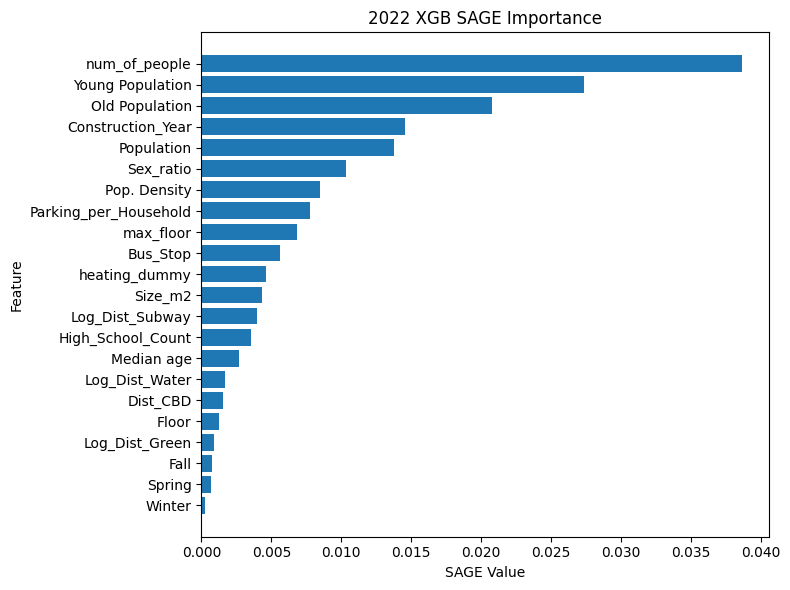


==================== 2023년 분석 시작 ====================
2023년 데이터 수: 31071

[2023년 XGB 성능]


,Year,Model,Train_R2,Test_R2,Train_RMSE,Test_RMSE,Train_N,Test_N
0,2023,XGB,0.95906,0.939687,0.087334,0.106442,21749,9322


2023년 SAGE 데이터 크기: (9322, 22)


  0%|          | 0/1 [00:00<?, ?it/s]


[2023년 XGB SAGE Importance]


,Feature,SAGE_Value,SAGE_STD,Year
0,Young Population,0.038103,0.000929,2023
1,Old Population,0.021183,0.000535,2023
2,num_of_people,0.020356,0.000790,2023
3,Construction_Year,0.019265,0.000544,2023
4,Population,0.013892,0.000437,2023
5,Parking_per_Household,0.006759,0.000287,2023
6,Sex_ratio,0.006672,0.000312,2023
7,Log_Dist_Subway,0.006564,0.000305,2023
8,Bus_Stop,0.006514,0.000256,2023
9,max_floor,0.006329,0.000228,2023


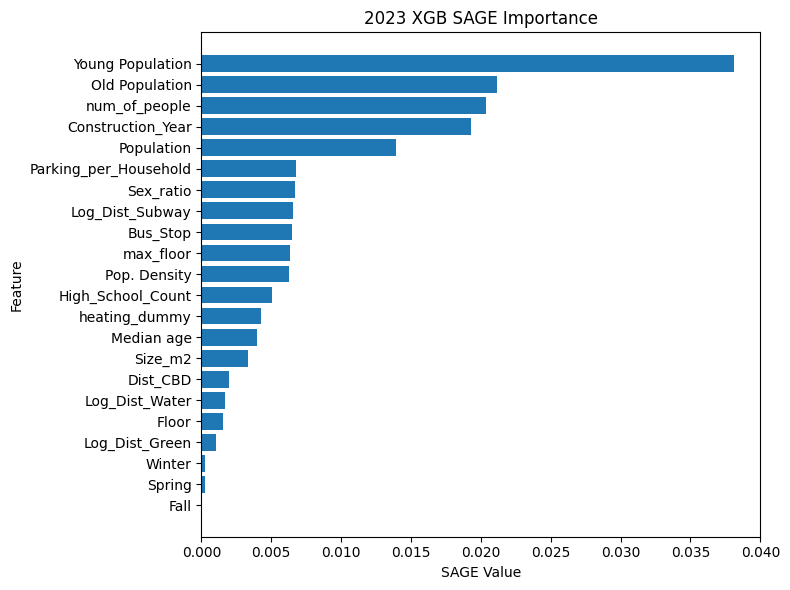


저장 완료: /content/drive/MyDrive/XGB_SAGE_By_Year.xlsx


In [1]:
# ============================================================
# 0. 설치
# ============================================================
!pip install sage-importance xgboost openpyxl -q

# ============================================================
# 1. 라이브러리
# ============================================================
import numpy as np
import pandas as pd
import sage
import matplotlib.pyplot as plt

from google.colab import drive
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor

# ============================================================
# 2. Google Drive 연결
# ============================================================
drive.mount('/content/drive', force_remount=True)

# ============================================================
# 3. 데이터 불러오기
# ============================================================
file_path = '/content/drive/MyDrive/Seoul_Aprtment_FINAL.xlsx'
df_raw = pd.read_excel(file_path)

print("원본 데이터 shape:", df_raw.shape)
display(df_raw.head())

# ============================================================
# 4. 전처리
# ============================================================
def prepare_df(df_input):
    df = df_input.copy()

    # heating 더미
    if "heating" in df.columns:
        df["heating_dummy"] = df["heating"].astype(str).apply(
            lambda x: 1 if ("도시가스" in x or x.strip() == "1") else 0
        )

    # 연도 변수 만들기
    if "Year_Sold" in df.columns:
        df["Year_Sold"] = pd.to_numeric(df["Year_Sold"], errors="coerce")

    elif "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
        df["Year_Sold"] = df["Date"].dt.year
        df["Month_Sold"] = df["Date"].dt.month

    elif "Sold_Date" in df.columns:
        df["Sold_Date"] = pd.to_datetime(df["Sold_Date"], errors="coerce")
        df["Year_Sold"] = df["Sold_Date"].dt.year
        df["Month_Sold"] = df["Sold_Date"].dt.month

    # 계절 더미
    if "Month_Sold" in df.columns:
        m = pd.to_numeric(df["Month_Sold"], errors="coerce")
        df["Spring"] = m.isin([3, 4, 5]).astype(int)
        df["Fall"]   = m.isin([9, 10, 11]).astype(int)
        df["Winter"] = m.isin([12, 1, 2]).astype(int)

    # 수치형 변환
    num_cols = [
        "Population","Sex_ratio","Pop. Density",
        "Old Population","Median age","Young Population",
        "Parking_per_Household",
        "Log_Dist_Water","Log_Dist_Green","Log_Dist_Subway",
        "Dist_CBD","max_floor","num_of_people",
        "Bus_Stop","High_School_Count",
        "Floor","Size_m2","Construction_Year",
        "Log_Price_per_m2","Year_Sold"
    ]

    for col in num_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

df = prepare_df(df_raw)

# ============================================================
# 5. 변수 설정
# ============================================================
target = "Log_Price_per_m2"

features = [
    "Population",
    "Sex_ratio",
    "Pop. Density",
    "Old Population",
    "Median age",
    "Young Population",
    "Parking_per_Household",
    "Log_Dist_Water",
    "Log_Dist_Green",
    "Log_Dist_Subway",
    "Dist_CBD",
    "max_floor",
    "heating_dummy",
    "num_of_people",
    "Bus_Stop",
    "High_School_Count",
    "Floor",
    "Size_m2",
    "Construction_Year",
    "Spring",
    "Fall",
    "Winter"
]

features = [c for c in features if c in df.columns]

print("\n사용 변수:")
print(features)

if "Year_Sold" not in df.columns:
    raise ValueError("Year_Sold 컬럼이 없습니다. Date 또는 Sold_Date에서 연도를 추출하도록 확인하세요.")

df_model = df.dropna(subset=features + [target, "Year_Sold"]).copy().reset_index(drop=True)

print("\n최종 데이터 shape:", df_model.shape)
print("\n연도별 개수:")
print(df_model["Year_Sold"].value_counts().sort_index())

# ============================================================
# 6~12. 연도별 XGB + SAGE
# ============================================================
years = [2022, 2023]

all_perf = []
all_sage = []

output_path = '/content/drive/MyDrive/XGB_SAGE_By_Year.xlsx'

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:

    for yr in years:
        print(f"\n==================== {yr}년 분석 시작 ====================")

        df_year = df_model[df_model["Year_Sold"] == yr].copy().reset_index(drop=True)

        print(f"{yr}년 데이터 수:", len(df_year))

        if len(df_year) < 10:
            print(f"{yr}년 데이터가 너무 적어서 건너뜁니다.")
            continue

        X = df_year[features]
        y = df_year[target]

        # train / test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=42
        )

        # XGB 학습
        xgb = XGBRegressor(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            objective='reg:squarederror',
            random_state=42,
            n_jobs=-1
        )
        xgb.fit(X_train, y_train)

        # 성능 평가
        pred_train = xgb.predict(X_train)
        pred_test = xgb.predict(X_test)

        xgb_result = pd.DataFrame([{
            "Year": yr,
            "Model": "XGB",
            "Train_R2": r2_score(y_train, pred_train),
            "Test_R2": r2_score(y_test, pred_test),
            "Train_RMSE": np.sqrt(mean_squared_error(y_train, pred_train)),
            "Test_RMSE": np.sqrt(mean_squared_error(y_test, pred_test)),
            "Train_N": len(X_train),
            "Test_N": len(X_test)
        }])

        print(f"\n[{yr}년 XGB 성능]")
        display(xgb_result)
        all_perf.append(xgb_result)

        # ============================================================
        # SAGE 계산
        # ============================================================
        X_sage = X_test.copy()
        y_sage = y_test.copy()

        print(f"{yr}년 SAGE 데이터 크기:", X_sage.shape)

        # background data
        background_size = min(512, len(X_train))
        X_background = X_train.sample(n=background_size, random_state=42)

        # SAGE용 imputer / estimator
        imputer = sage.MarginalImputer(xgb, X_background.values)
        estimator = sage.PermutationEstimator(imputer, loss='mse', random_state=42)

        # 계산량이 너무 많을 수 있으므로 필요시 샘플링
        # 전체 테스트셋 다 쓰고 싶으면 아래 두 줄은 그대로 둬도 됨
        X_sage_eval = X_sage.copy()
        y_sage_eval = y_sage.copy()

        sage_values = estimator(X_sage_eval.values, y_sage_eval.values)

        xgb_importance = pd.DataFrame({
            "Feature": features,
            "SAGE_Value": sage_values.values
        })

        if hasattr(sage_values, "std"):
            xgb_importance["SAGE_STD"] = sage_values.std

        xgb_importance["Year"] = yr
        xgb_importance = xgb_importance.sort_values(
            by="SAGE_Value", ascending=False
        ).reset_index(drop=True)

        all_sage.append(xgb_importance)

        print(f"\n[{yr}년 XGB SAGE Importance]")
        display(xgb_importance)

        # 엑셀 저장
        xgb_result.to_excel(writer, sheet_name=f'{yr}_Perf', index=False)
        xgb_importance.to_excel(writer, sheet_name=f'{yr}_SAGE', index=False)

        # 그래프 출력
        plt.figure(figsize=(8, 6))
        plt.barh(
            xgb_importance["Feature"][::-1],
            xgb_importance["SAGE_Value"][::-1]
        )
        plt.xlabel("SAGE Value")
        plt.ylabel("Feature")
        plt.title(f"{yr} XGB SAGE Importance")
        plt.tight_layout()
        plt.show()

    # 전체 성능표 저장
    if len(all_perf) > 0:
        perf_all_df = pd.concat(all_perf, axis=0).reset_index(drop=True)
        perf_all_df.to_excel(writer, sheet_name='All_Performance', index=False)

    # 전체 SAGE 저장
    if len(all_sage) > 0:
        sage_all_df = pd.concat(all_sage, axis=0).reset_index(drop=True)
        sage_all_df.to_excel(writer, sheet_name='All_SAGE', index=False)

print("\n저장 완료:", output_path)